In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import kagglehub

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
path = kagglehub.dataset_download("datamunge/sign-language-mnist")
print("Path to dataset files:", path)

train_df = pd.read_csv(f"{path}/sign_mnist_train.csv")
test_df  = pd.read_csv(f"{path}/sign_mnist_test.csv")

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Path to dataset files: /kaggle/input/sign-language-mnist


In [4]:
def df_to_tensors(df):
    labels = df["label"].values
    pixels = df.drop("label", axis=1).values.astype(np.float32) / 255.0
    X = pixels.reshape(-1, 1, 28, 28)
    X = torch.tensor(X)
    y = torch.tensor(labels, dtype=torch.long)
    return X, y

# Apply LabelEncoder to ensure contiguous labels (0 to 23)
encoder = LabelEncoder()
train_df["label"] = encoder.fit_transform(train_df["label"])
test_df["label"] = encoder.transform(test_df["label"])

X_train, y_train = df_to_tensors(train_df)
X_test,  y_test  = df_to_tensors(test_df)

# Train / Validation split (80/20 of training data)
val_size  = int(0.2 * len(X_train))
train_size = len(X_train) - val_size
indices    = torch.randperm(len(X_train))

X_val,   y_val   = X_train[indices[:val_size]],   y_train[indices[:val_size]]
X_train, y_train = X_train[indices[val_size:]],  y_train[indices[val_size:]]

print(f"\nSplit → Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE)


Split → Train: 21964  Val: 5491  Test: 7172


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=24):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

num_classes = len(train_df["label"].unique())
model = SimpleCNN(num_classes=num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())

In [6]:
EPOCHS    = 20
LR        = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total

In [ ]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(y_batch)
        correct      += (logits.argmax(1) == y_batch).sum().item()
        total        += len(y_batch)

    train_loss = running_loss / total
    train_acc  = correct / total
    val_loss, val_acc = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

Epoch 01/20 | Train Loss: 1.4524  Acc: 0.5479 | Val Loss: 0.3767  Acc: 0.8973
Epoch 02/20 | Train Loss: 0.3377  Acc: 0.8872 | Val Loss: 0.0827  Acc: 0.9825
Epoch 04/20 | Train Loss: 0.0886  Acc: 0.9720 | Val Loss: 0.0088  Acc: 1.0000
Epoch 06/20 | Train Loss: 0.0364  Acc: 0.9896 | Val Loss: 0.0028  Acc: 0.9995
Epoch 08/20 | Train Loss: 0.0287  Acc: 0.9908 | Val Loss: 0.0015  Acc: 1.0000
Epoch 10/20 | Train Loss: 0.0227  Acc: 0.9931 | Val Loss: 0.0011  Acc: 1.0000
Epoch 12/20 | Train Loss: 0.0187  Acc: 0.9943 | Val Loss: 0.0004  Acc: 1.0000
Epoch 14/20 | Train Loss: 0.0175  Acc: 0.9949 | Val Loss: 0.0003  Acc: 1.0000
Epoch 16/20 | Train Loss: 0.0162  Acc: 0.9942 | Val Loss: 0.0008  Acc: 1.0000
Epoch 18/20 | Train Loss: 0.0153  Acc: 0.9948 | Val Loss: 0.0003  Acc: 1.0000


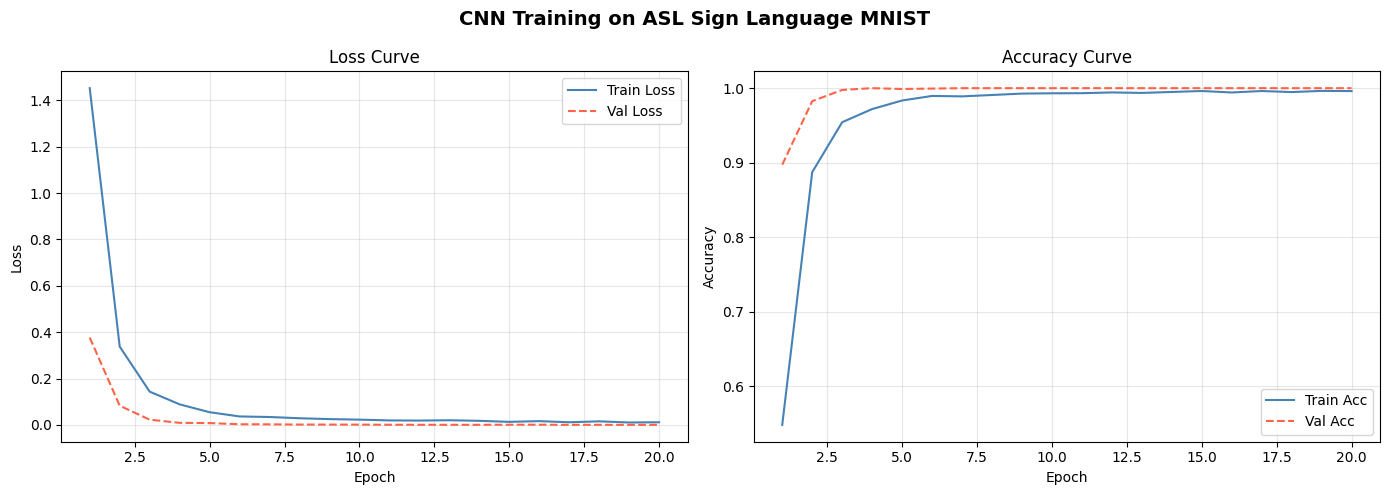

Saved: training_curves.png


In [ ]:
import os

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN Training on ASL Sign Language MNIST", fontsize=14, fontweight="bold")

# Loss curve
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   color="tomato", linestyle="--")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", color="steelblue")
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   color="tomato", linestyle="--")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Create the directory if it does not exist
output_dir = "/mnt/user-data/outputs/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

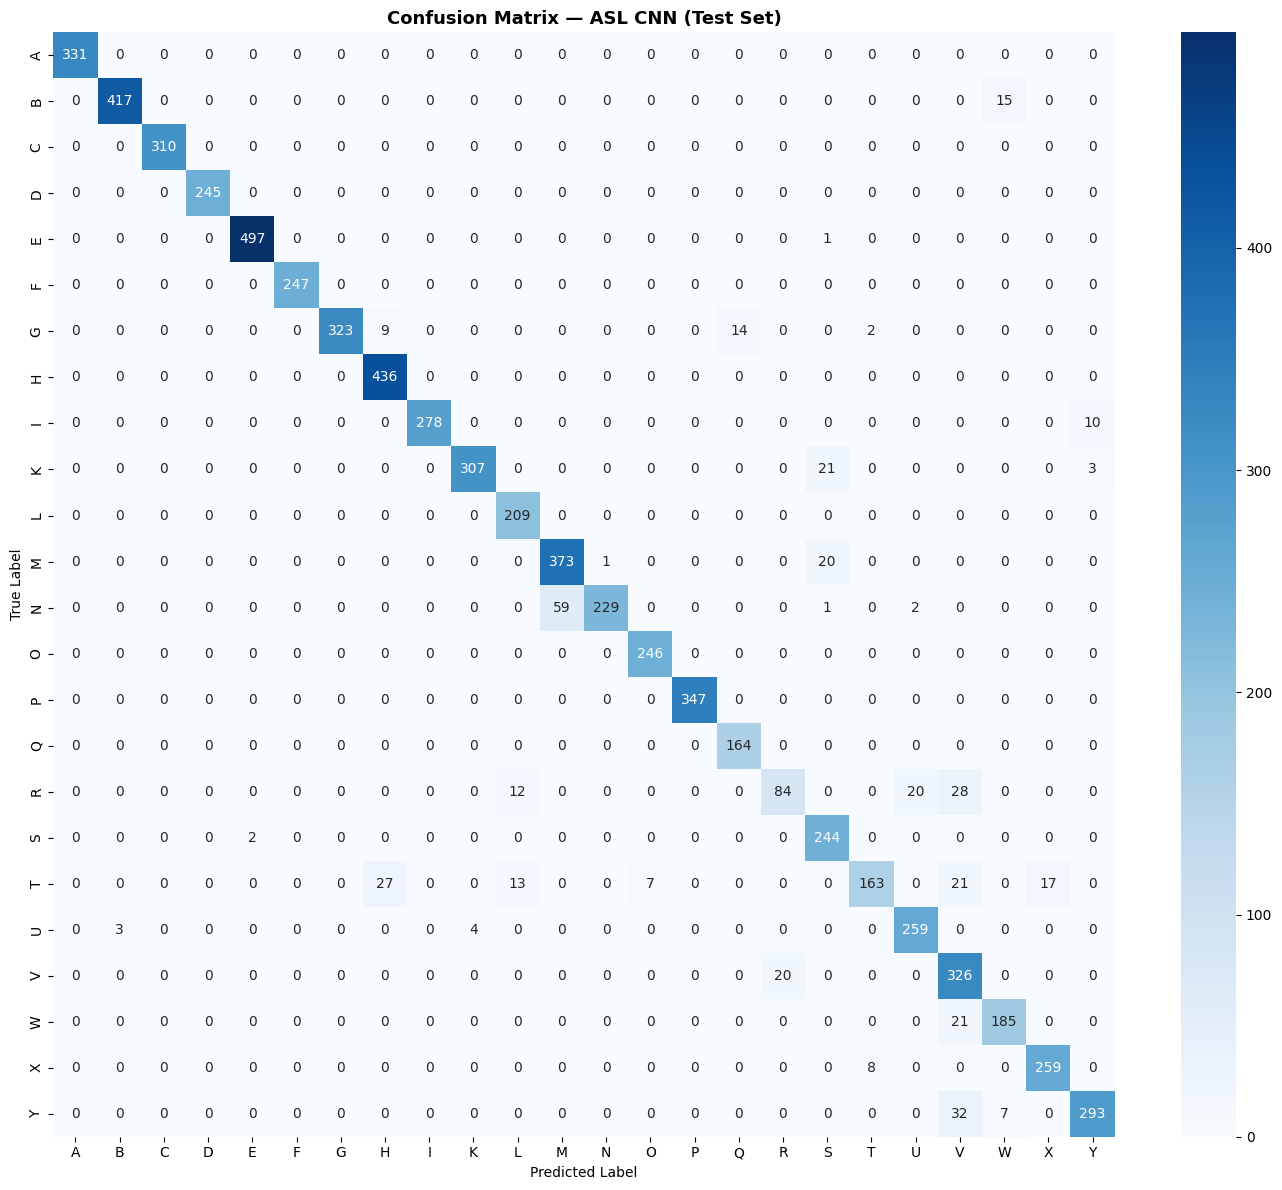

Saved: confusion_matrix.png


In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

# ASL labels (J=9 and Z=25 are motion signs, excluded from dataset)
label_names = [chr(ord('A') + i) for i in range(26) if i not in [9, 25]]

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix — ASL CNN (Test Set)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

In [ ]:
print(classification_report(all_labels, all_preds, target_names=label_names))

# 10. Overfitting / Underfitting Diagnosis
print("\n── Model Diagnosis ───────────────────────────────────────")
final_train_acc = history["train_acc"][-1]
final_val_acc   = history["val_acc"][-1]
gap = final_train_acc - final_val_acc

print(f"Final Train Accuracy : {final_train_acc*100:.2f}%")
print(f"Final Val   Accuracy : {final_val_acc*100:.2f}%")
print(f"Train-Val Gap        : {gap*100:.2f}%")

if final_train_acc < 0.70:
    verdict = "UNDERFITTING — model is too simple or undertrained."
elif gap > 0.15:
    verdict = "OVERFITTING — large gap between train and val accuracy."
elif final_val_acc >= 0.85:
    verdict = "GOOD FIT — model generalizes well."
else:
    verdict = "MODERATE FIT — decent performance, room to improve."

print(f"\nVerdict: {verdict}")
print("""
Interpretation Guide:
  • Overfitting  → Train acc >> Val acc (gap > ~15%)
  • Underfitting → Both train & val acc are low (< 70%)
  • Good fit     → Train ≈ Val acc, both high (≥ 85%)
""")

              precision    recall  f1-score   support

           A       1.00      0.97      0.98       331
           B       0.99      0.95      0.97       432
           C       1.00      0.97      0.99       310
           D       0.91      1.00      0.95       245
           E       0.98      0.99      0.99       498
           F       0.97      1.00      0.98       247
           G       0.93      0.84      0.89       348
           H       0.92      0.95      0.93       436
           I       0.97      0.92      0.95       288
           K       0.93      0.92      0.93       331
           L       0.89      1.00      0.94       209
           M       0.99      0.90      0.94       394
           N       0.90      1.00      0.94       291
           O       1.00      0.92      0.96       246
           P       1.00      1.00      1.00       347
           Q       0.82      1.00      0.90       164
           R       0.88      0.72      0.79       144
           S       0.74    